
## Stats annotation  (April 23rd 2025)


In [1]:
import numpy as np
import pandas as pd
import scipy.integrate
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib import animation, rc
from IPython.display import HTML
import time
import multiprocessing as mp
import os

from scipy.stats import zscore

from sklearn.manifold import TSNE
from sklearn.mixture import BayesianGaussianMixture

import phenograph as pg
import random

In [2]:
colours_30 = ["firebrick","gold","royalblue","green","dimgray","orchid","darkviolet",
              "red", "orange", "limegreen", "blue", "purple", "seagreen","gold","darkolivegreen",
              "lightpink","thistle","mistyrose","saddlebrown","slategrey","powderblue",
            "palevioletred","mediumvioletred","yellowgreen","lemonchiffon","chocolate",
              "lightsalmon","lightcyan","lightblue", "darkorange","magenta","sienna","midnightblue","fuchsia","violet","tomato","aqua",
             "darkslategray","coral","lightcoral","sandybrown","indianred","olivedrab","darkgreen","blueviolet","forestgreen","darkred",
             "dimgray","teal","cadetblue"]

In [3]:
## read in data

count_matrix_A_pre =  np.array(pd.read_csv(os.path.join('nonspatial/ArmA_pre.csv'), header=0,index_col=None))
count_matrix_B_pre =  np.array(pd.read_csv(os.path.join('nonspatial/ArmB_pre.csv'), header=0,index_col=None))
count_matrix_A_dur =  np.array(pd.read_csv(os.path.join('nonspatial/ArmA_dur.csv'), header=0,index_col=None))
count_matrix_B_dur =  np.array(pd.read_csv(os.path.join('nonspatial/ArmB_dur.csv'), header=0,index_col=None))

In [4]:
print(count_matrix_A_dur.shape)
print(count_matrix_A_pre.shape)
print(count_matrix_B_dur.shape)
print(count_matrix_B_pre.shape)


(22, 207)
(19, 207)
(16, 207)
(17, 207)


In [6]:
num_pat_A_pre = count_matrix_A_pre.shape[0]
num_pat_A_dur = count_matrix_A_dur.shape[0]
num_pat_B_pre = count_matrix_B_pre.shape[0]
num_pat_B_dur = count_matrix_B_dur.shape[0]

In [ ]:
### collecting stats for A pre

plt.figure(100, figsize=(4,4),dpi=200)
plt.axis('off')


y_marker = ['FoxP3','CD3',  'CD8', 'PD1','PDL1' ]

## A pre

fox_A_pre_list_t= count_matrix_A_pre[:,102]
cd3_A_pre_list_t= count_matrix_A_pre[:,103]
cd8_A_pre_list_t= count_matrix_A_pre[:,104]
pd1_A_pre_list_t= count_matrix_A_pre[:,105]
pdl1_A_pre_list_t= count_matrix_A_pre[:,106]

fox_A_pre_list_s= count_matrix_A_pre[:,167]
cd3_A_pre_list_s= count_matrix_A_pre[:,168]
cd8_A_pre_list_s= count_matrix_A_pre[:,169]
pd1_A_pre_list_s= count_matrix_A_pre[:,170]
pdl1_A_pre_list_s= count_matrix_A_pre[:,171]

cd3_fox_A_pre_list_t= count_matrix_A_pre[:,119]
cd3_cd8_A_pre_list_t= count_matrix_A_pre[:,120]
cd3_pd1_A_pre_list_t= count_matrix_A_pre[:,121]
cd8_pd1_A_pre_list_t= count_matrix_A_pre[:,122]


cd3_fox_A_pre_list_s= count_matrix_A_pre[:,184]
cd3_cd8_A_pre_list_s= count_matrix_A_pre[:,185]
cd3_pd1_A_pre_list_s= count_matrix_A_pre[:,186]
cd8_pd1_A_pre_list_s= count_matrix_A_pre[:,187]

#### A dur

fox_A_dur_list_t= count_matrix_A_dur[:,102]
cd3_A_dur_list_t= count_matrix_A_dur[:,103]
cd8_A_dur_list_t= count_matrix_A_dur[:,104]
pd1_A_dur_list_t= count_matrix_A_dur[:,105]
pdl1_A_dur_list_t= count_matrix_A_dur[:,106]

fox_A_dur_list_s= count_matrix_A_dur[:,167]
cd3_A_dur_list_s= count_matrix_A_dur[:,168]
cd8_A_dur_list_s= count_matrix_A_dur[:,169]
pd1_A_dur_list_s= count_matrix_A_dur[:,170]
pdl1_A_dur_list_s= count_matrix_A_dur[:,171]

cd3_fox_A_dur_list_t= count_matrix_A_dur[:,119]
cd3_cd8_A_dur_list_t= count_matrix_A_dur[:,120]
cd3_pd1_A_dur_list_t= count_matrix_A_dur[:,121]
cd8_pd1_A_dur_list_t= count_matrix_A_dur[:,122]


cd3_fox_A_dur_list_s= count_matrix_A_dur[:,184]
cd3_cd8_A_dur_list_s= count_matrix_A_dur[:,185]
cd3_pd1_A_dur_list_s= count_matrix_A_dur[:,186]
cd8_pd1_A_dur_list_s= count_matrix_A_dur[:,187]


## B pre
fox_B_pre_list_t= count_matrix_B_pre[:,102]
cd3_B_pre_list_t= count_matrix_B_pre[:,103]
cd8_B_pre_list_t= count_matrix_B_pre[:,104]
pd1_B_pre_list_t= count_matrix_B_pre[:,105]
pdl1_B_pre_list_t= count_matrix_B_pre[:,106]

fox_B_pre_list_s= count_matrix_B_pre[:,167]
cd3_B_pre_list_s= count_matrix_B_pre[:,168]
cd8_B_pre_list_s= count_matrix_B_pre[:,169]
pd1_B_pre_list_s= count_matrix_B_pre[:,170]
pdl1_B_pre_list_s= count_matrix_B_pre[:,171]

cd3_fox_B_pre_list_t= count_matrix_B_pre[:,119]
cd3_cd8_B_pre_list_t= count_matrix_B_pre[:,120]
cd3_pd1_B_pre_list_t= count_matrix_B_pre[:,121]
cd8_pd1_B_pre_list_t= count_matrix_B_pre[:,122]


cd3_fox_B_pre_list_s= count_matrix_B_pre[:,184]
cd3_cd8_B_pre_list_s= count_matrix_B_pre[:,185]
cd3_pd1_B_pre_list_s= count_matrix_B_pre[:,186]
cd8_pd1_B_pre_list_s= count_matrix_B_pre[:,187]

#### B dur

fox_B_dur_list_t= count_matrix_B_dur[:,102]
cd3_B_dur_list_t= count_matrix_B_dur[:,103]
cd8_B_dur_list_t= count_matrix_B_dur[:,104]
pd1_B_dur_list_t= count_matrix_B_dur[:,105]
pdl1_B_dur_list_t= count_matrix_B_dur[:,106]

fox_B_dur_list_s= count_matrix_B_dur[:,167]
cd3_B_dur_list_s= count_matrix_B_dur[:,168]
cd8_B_dur_list_s= count_matrix_B_dur[:,169]
pd1_B_dur_list_s= count_matrix_B_dur[:,170]
pdl1_B_dur_list_s= count_matrix_B_dur[:,171]

cd3_fox_B_dur_list_t= count_matrix_B_dur[:,119]
cd3_cd8_B_dur_list_t= count_matrix_B_dur[:,120]
cd3_pd1_B_dur_list_t= count_matrix_B_dur[:,121]
cd8_pd1_B_dur_list_t= count_matrix_B_dur[:,122]


cd3_fox_B_dur_list_s= count_matrix_B_dur[:,184]
cd3_cd8_B_dur_list_s= count_matrix_B_dur[:,185]
cd3_pd1_B_dur_list_s= count_matrix_B_dur[:,186]
cd8_pd1_B_dur_list_s= count_matrix_B_dur[:,187]



In [9]:
def asteriskscheck(pval):
    if stats_results["p-val"].values<=0.0001:
        asterisks="****"
    elif stats_results["p-val"].values<=0.001: 
        asterisks="***"
    elif stats_results["p-val"].values<=0.01: 
        asterisks="**"
    elif stats_results["p-val"].values<=0.05: 
        asterisks="*"
    else: 
        asterisks="n.s."
    return asterisks

p-value: 0.2806
p-value: 0.1277
p-value: 0.9406
p-value: 0.3872
p-value: 0.3968
p-value: 0.1699


<Figure size 1600x1200 with 0 Axes>

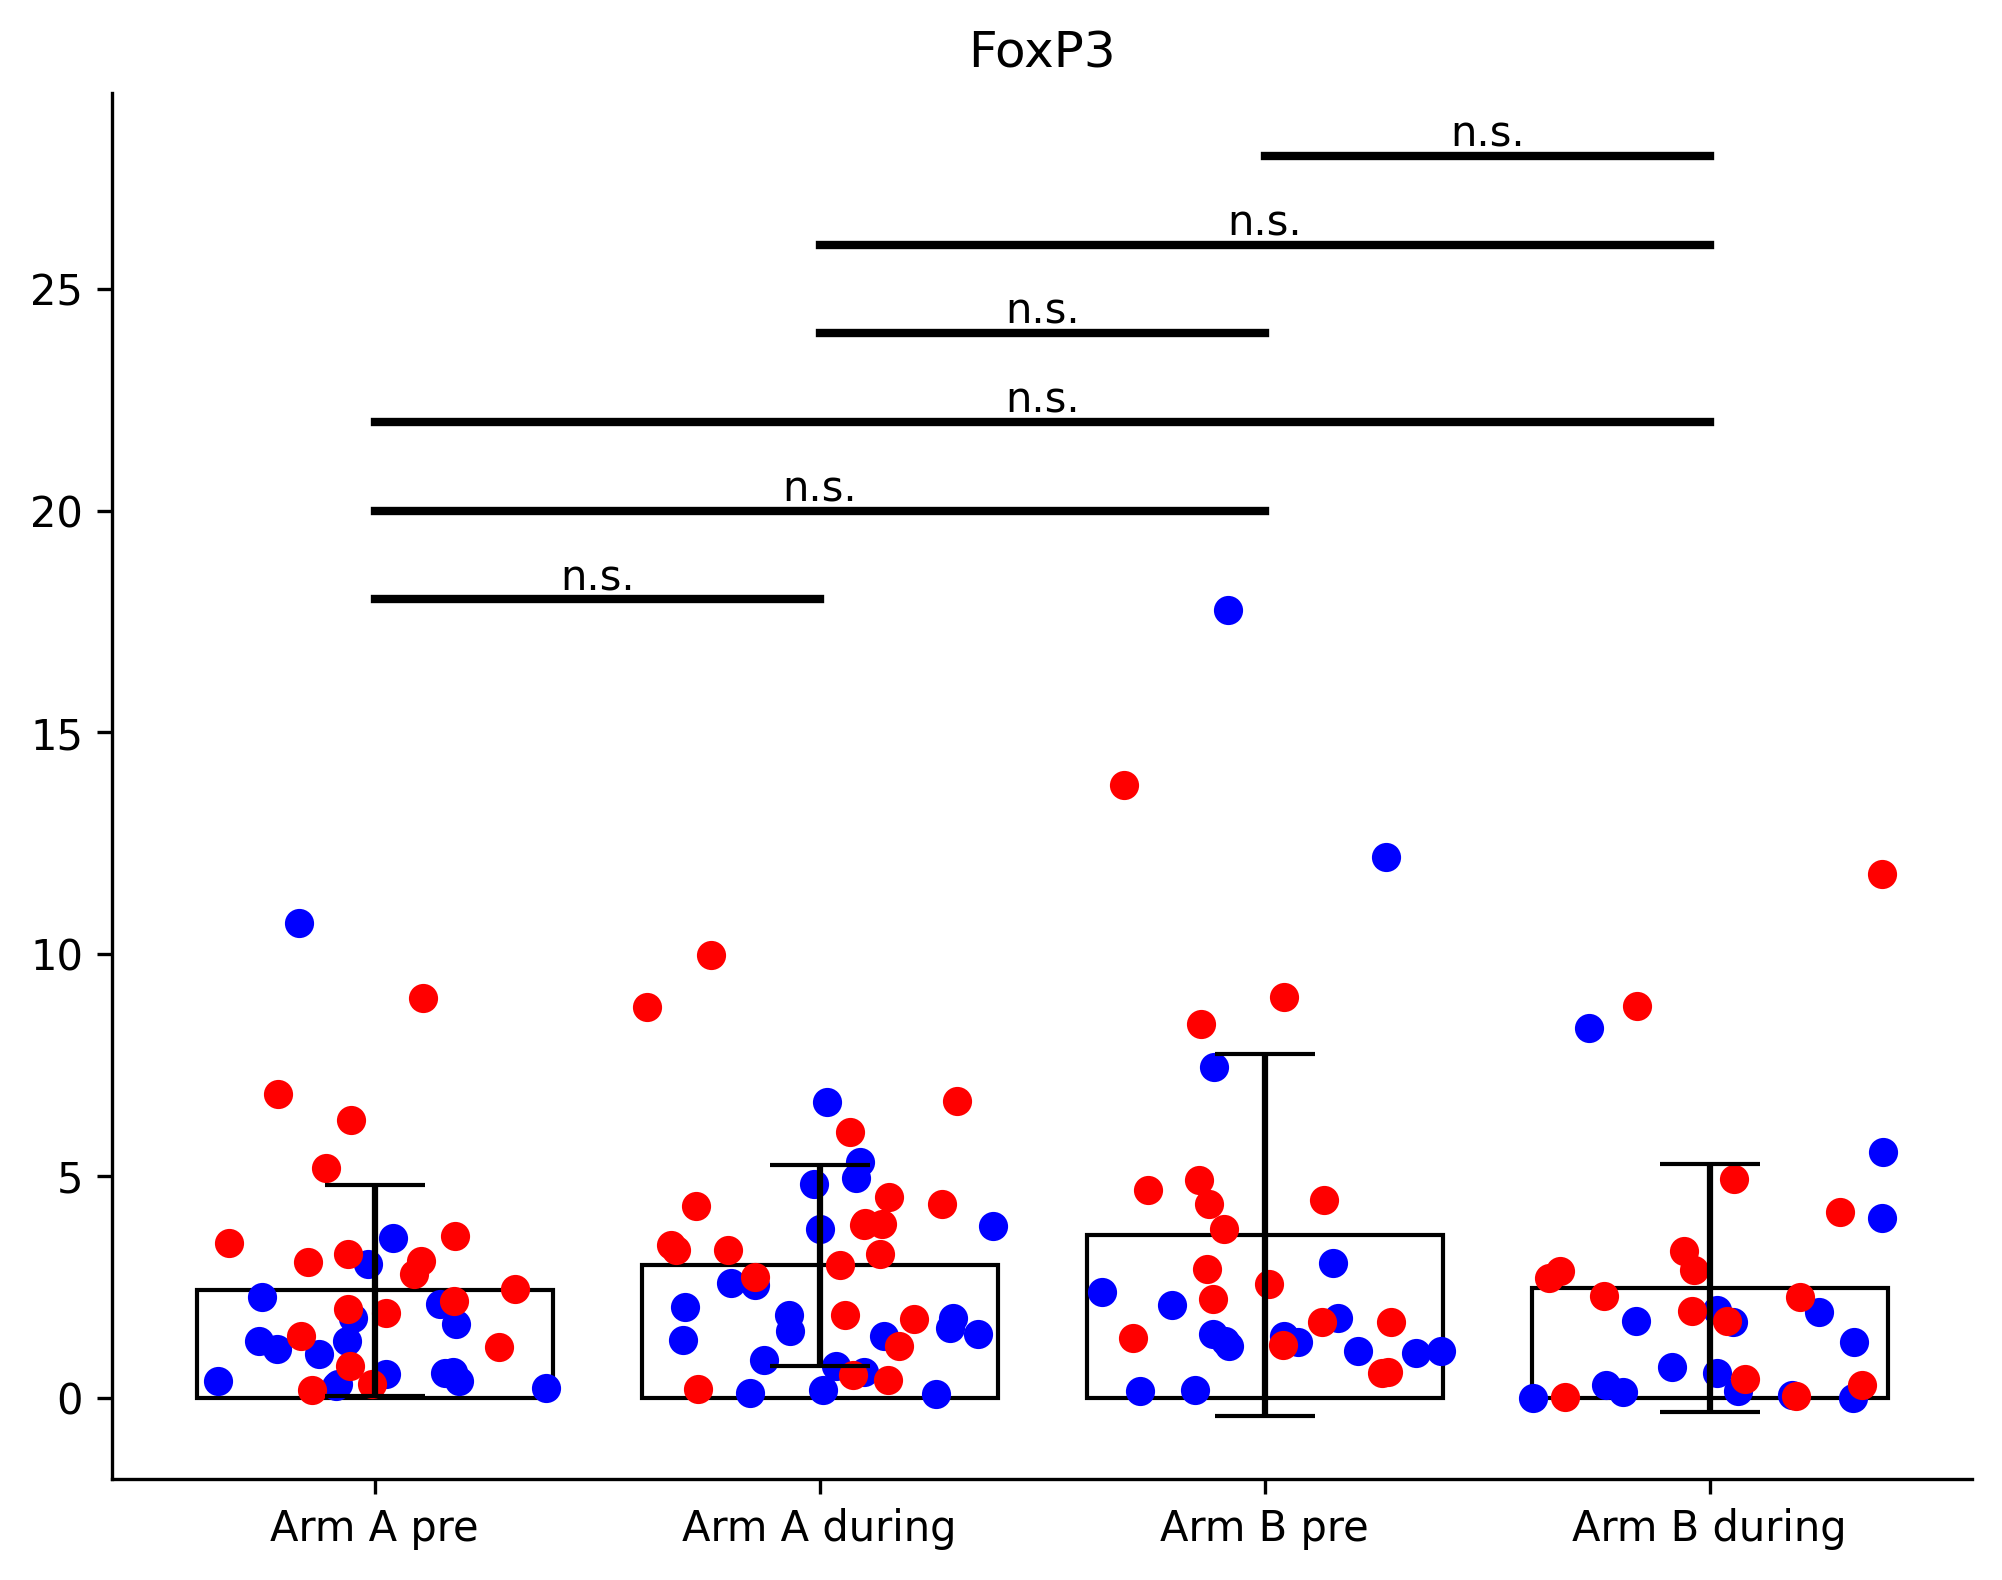

In [10]:
## this code generates the scatter plot for all time points for foxp3


np.random.seed(123)

plt.figure(figsize=[8,6],dpi=200)


tx_size = 2.0
fs= 10

#f_a_pre = np.reshape([fox_A_pre_list],[num_pat_A_pre,2])
f_a_pre_stack = np.array(np.concatenate([fox_A_pre_list_t,fox_A_pre_list_s],axis=0),dtype=float)

#f_a_dur = np.reshape([fox_A_dur_list],[num_pat_A_dur,2])
f_a_dur_stack = np.array(np.concatenate([fox_A_dur_list_t,fox_A_dur_list_s],axis=0),dtype=float)

#f_b_pre = np.reshape([fox_B_pre_list],[num_pat_B_pre,2])
f_b_pre_stack = np.array(np.concatenate([fox_B_pre_list_t,fox_B_pre_list_s],axis=0),dtype=float)

#f_b_dur = np.reshape([fox_B_dur_list],[num_pat_B_dur,2])
f_b_dur_stack = np.array(np.concatenate([fox_B_dur_list_t,fox_B_dur_list_s],axis=0),dtype=float)

'''stats annotation '''

import pingouin as pg
stats_results = pg.ttest(f_a_pre_stack, f_a_dur_stack, paired=False)
p_val_apre_adur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_adur}")

stats_results = pg.ttest(f_a_pre_stack, f_b_pre_stack, paired=False)
p_val_apre_bpre = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_bpre}")

stats_results = pg.ttest(f_a_pre_stack, f_b_dur_stack, paired=False)
p_val_apre_bdur= stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_bdur}")

stats_results = pg.ttest(f_a_dur_stack, f_b_pre_stack, paired=False)
p_val_adur_bpre = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_adur_bpre}")

stats_results = pg.ttest(f_a_dur_stack, f_b_dur_stack, paired=False)
p_val_adur_bdur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_adur_bdur}")

stats_results = pg.ttest(f_b_pre_stack, f_b_dur_stack, paired=False)
p_val_bpre_bdur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_bpre_bdur}")



l_f_a_pre_stack = np.int64(len(f_a_pre_stack)/2)
l_f_a_dur_stack = np.int64(len(f_a_dur_stack)/2)
l_f_b_pre_stack = np.int64(len(f_b_pre_stack)/2)
l_f_b_dur_stack = np.int64(len(f_b_dur_stack)/2)

w = 0.8    # bar width
x = [1,2,3,4] # x-coordinates of your bars
colors = ['black', 'black', 'black', 'black',(0, 0, 1, 1), (1, 0, 0, 1)]    # corresponding colors
y = [f_a_pre_stack, f_a_dur_stack, f_b_pre_stack, f_b_dur_stack] #,       # data series
    #np.random.random(10) * 3 + 8]

fig, ax = plt.subplots(figsize=[8,6],dpi=300)
ax.bar(x,
       height=[np.mean(yi) for yi in y],
       yerr=[np.std(yi) for yi in y],    # error bars
       capsize=12, # error bar cap width in points
       width=w,    # bar width
       tick_label=["Arm A pre","Arm A during","Arm B pre","Arm B during" ],
       color=(0,0,0,0),  # face color transparent
       edgecolor=colors,
       #ecolor=colors,    # error bar colors;
       )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.xticks(rotation=45)

pat_num = [num_pat_A_pre,num_pat_A_dur,num_pat_B_pre,num_pat_B_dur]
l_ff = [l_f_a_pre_stack,l_f_a_dur_stack,l_f_b_pre_stack,l_f_b_dur_stack]

for i in range(len(x)):
    # distribute scatter randomly across whole width of bar
    ax.scatter(x[i] + np.random.random(l_ff[i]) * w - w / 2, y[i][0:pat_num[i]], color='blue') #colors[i] #tumor
    ax.scatter(x[i] + np.random.random(l_ff[i]) * w - w / 2, y[i][pat_num[i]:pat_num[i]*2], color='red') #colors[i] #stroma

# statistical annotations:
h = 18 # height of the horizontal bar
annotation_offset = 0.01 # offset of the stats-annotation
ax.plot([1, 2], [h, h], '-k', lw=tx_size)
ax.text(1.5, h+annotation_offset, 
         asteriskscheck(p_val_apre_bpre), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)
h = 20 
annotation_offset = 0.01 
ax.plot([1, 3], [h, h], '-k', lw=tx_size)
ax.text(2, h+annotation_offset, 
         asteriskscheck(p_val_apre_adur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 22 
ax.plot([1, 4], [h, h], '-k', lw=tx_size)
annotation_offset = 0.01 
ax.text(2.5, h+annotation_offset, 
         asteriskscheck(p_val_apre_bdur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 24
annotation_offset = 0.01 
ax.plot([2,3], [h, h], '-k', lw=tx_size)
ax.text(2.5, h+annotation_offset, 
         asteriskscheck(p_val_adur_bpre), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 26
annotation_offset = 0.01
ax.plot([2,4], [h, h], '-k', lw=tx_size)
ax.text(3, h+annotation_offset, 
         asteriskscheck(p_val_adur_bdur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)


h = 28
annotation_offset = 0.01 
ax.plot([3,4], [h, h], '-k', lw=tx_size)
ax.text(3.5, h+annotation_offset, 
         asteriskscheck(p_val_bpre_bdur),
         ha='center', va='bottom', fontsize=fs)

plt.title('FoxP3')

plt.show()

In [11]:
f_a_pre_stack

array([ 0.563867, 10.702504,  1.087942,  3.592814,  0.585849,  1.28123 ,
        0.208768,  2.104528,  3.021719,  0.266381,  0.981782,  1.651869,
        1.804769,  0.385888,  0.310881,  0.382702,  2.275425,  1.281305,
        0.5308  ,  1.899776,  9.017199,  1.143674,  3.650935,  2.793781,
        2.190605,  0.167551,  5.177818,  6.85213 ,  1.397221,  3.089198,
        3.498461,  6.263841,  0.708923,  0.306663,  1.991465,  3.068123,
        3.237812,  2.453863])

In [12]:
pv=[p_val_apre_adur,p_val_apre_bpre,p_val_apre_bdur,p_val_adur_bpre,p_val_adur_bdur,p_val_bpre_bdur]
reject, pvals_corr = pg.multicomp(pv, method='holm')
print(reject, pvals_corr)
print(pv)

[False False False False False False] [1.     0.7662 1.     1.     1.     0.8495]
[0.2806, 0.1277, 0.9406, 0.3872, 0.3968, 0.1699]


p-value: 0.012
p-value: 0.2097
p-value: 0.0648
p-value: 0.8305
p-value: 0.6114
p-value: 0.5638


<Figure size 1600x1200 with 0 Axes>

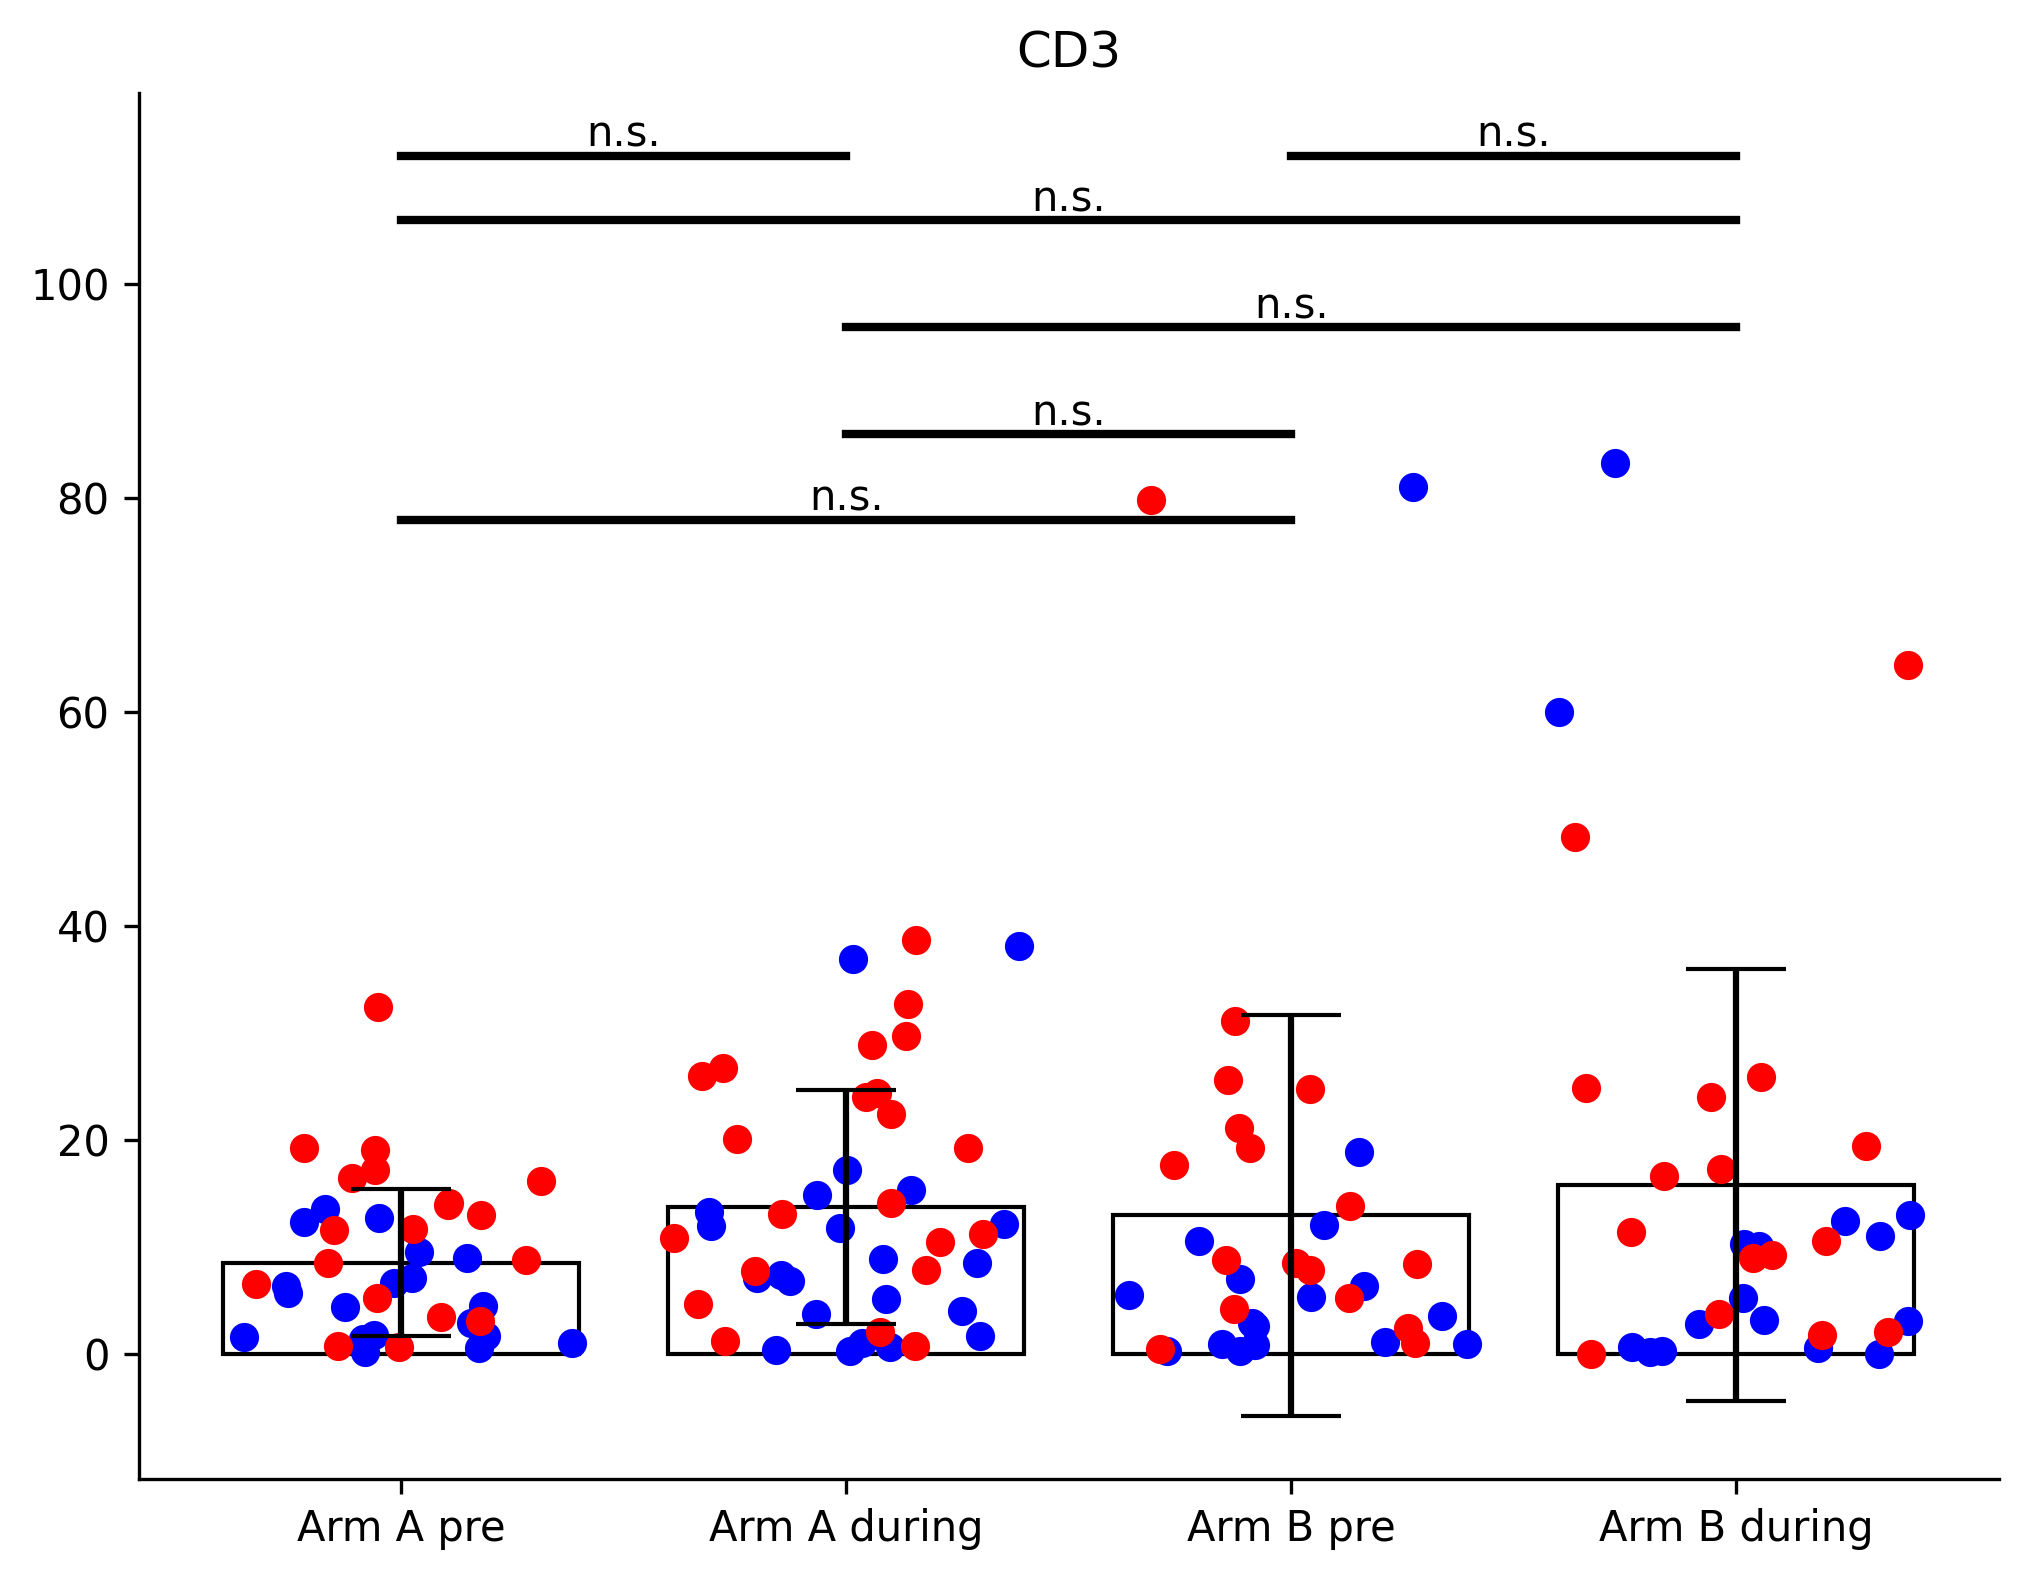

In [14]:
## this code generates the scatter plot for all time points for cd3


np.random.seed(123)

plt.figure(figsize=[8,6],dpi=200)


tx_size = 2.0
fs= 10

#f_a_pre = np.reshape([fox_A_pre_list],[num_pat_A_pre,2])
f_a_pre_stack = np.array(np.concatenate([cd3_A_pre_list_t,cd3_A_pre_list_s],axis=0),dtype=float)

#f_a_dur = np.reshape([fox_A_dur_list],[num_pat_A_dur,2])
f_a_dur_stack = np.array(np.concatenate([cd3_A_dur_list_t,cd3_A_dur_list_s],axis=0),dtype=float)

#f_b_pre = np.reshape([fox_B_pre_list],[num_pat_B_pre,2])
f_b_pre_stack = np.array(np.concatenate([cd3_B_pre_list_t,cd3_B_pre_list_s],axis=0),dtype=float)

#f_b_dur = np.reshape([fox_B_dur_list],[num_pat_B_dur,2])
f_b_dur_stack = np.array(np.concatenate([cd3_B_dur_list_t,cd3_B_dur_list_s],axis=0),dtype=float)

'''stats annotation '''

import pingouin as pg
stats_results = pg.ttest(f_a_pre_stack, f_a_dur_stack, paired=False)
p_val_apre_adur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_adur}")

stats_results = pg.ttest(f_a_pre_stack, f_b_pre_stack, paired=False)
p_val_apre_bpre = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_bpre}")

stats_results = pg.ttest(f_a_pre_stack, f_b_dur_stack, paired=False)
p_val_apre_bdur= stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_bdur}")

stats_results = pg.ttest(f_a_dur_stack, f_b_pre_stack, paired=False)
p_val_adur_bpre = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_adur_bpre}")

stats_results = pg.ttest(f_a_dur_stack, f_b_dur_stack, paired=False)
p_val_adur_bdur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_adur_bdur}")

stats_results = pg.ttest(f_b_pre_stack, f_b_dur_stack, paired=False)
p_val_bpre_bdur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_bpre_bdur}")



l_f_a_pre_stack = np.int64(len(f_a_pre_stack)/2)
l_f_a_dur_stack = np.int64(len(f_a_dur_stack)/2)
l_f_b_pre_stack = np.int64(len(f_b_pre_stack)/2)
l_f_b_dur_stack = np.int64(len(f_b_dur_stack)/2)

w = 0.8    # bar width
x = [1,2,3,4] # x-coordinates of your bars
colors = ['black', 'black', 'black', 'black',(0, 0, 1, 1), (1, 0, 0, 1)]    # corresponding colors
y = [f_a_pre_stack, f_a_dur_stack, f_b_pre_stack, f_b_dur_stack] #,       # data series
    #np.random.random(10) * 3 + 8]

fig, ax = plt.subplots(figsize=[8,6],dpi=300)
ax.bar(x,
       height=[np.mean(yi) for yi in y],
       yerr=[np.std(yi) for yi in y],    # error bars
       capsize=12, # error bar cap width in points
       width=w,    # bar width
       tick_label=["Arm A pre","Arm A during","Arm B pre","Arm B during" ],
       color=(0,0,0,0),  # face color transparent
       edgecolor=colors,
       #ecolor=colors,    # error bar colors; 
       )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.xticks(rotation=45)

pat_num = [num_pat_A_pre,num_pat_A_dur,num_pat_B_pre,num_pat_B_dur]
l_ff = [l_f_a_pre_stack,l_f_a_dur_stack,l_f_b_pre_stack,l_f_b_dur_stack]

for i in range(len(x)):
    # distribute scatter randomly across whole width of bar
    ax.scatter(x[i] + np.random.random(l_ff[i]) * w - w / 2, y[i][0:pat_num[i]], color='blue') #colors[i] #tumor
    ax.scatter(x[i] + np.random.random(l_ff[i]) * w - w / 2, y[i][pat_num[i]:pat_num[i]*2], color='red') #colors[i] #stroma

# statistical annotations:
h = 112 # height of the horizontal bar
annotation_offset = 0.01 # offset of the stats-annotation
ax.plot([1, 2], [h, h], '-k', lw=tx_size)
ax.text(1.5, h+annotation_offset, 
         asteriskscheck(p_val_apre_bpre), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)
h = 78 
annotation_offset = 0.01 
ax.plot([1, 3], [h, h], '-k', lw=tx_size)
ax.text(2, h+annotation_offset, 
         asteriskscheck(p_val_apre_adur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 106
ax.plot([1, 4], [h, h], '-k', lw=tx_size)
annotation_offset = 0.01 
ax.text(2.5, h+annotation_offset, 
         asteriskscheck(p_val_apre_bdur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 86
annotation_offset = 0.01 
ax.plot([2,3], [h, h], '-k', lw=tx_size)
ax.text(2.5, h+annotation_offset, 
         asteriskscheck(p_val_adur_bpre), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 96 
annotation_offset = 0.01
ax.plot([2,4], [h, h], '-k', lw=tx_size)
ax.text(3, h+annotation_offset, 
         asteriskscheck(p_val_adur_bdur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)


h = 112 
annotation_offset = 0.01 
ax.plot([3,4], [h, h], '-k', lw=tx_size)
ax.text(3.5, h+annotation_offset, 
         asteriskscheck(p_val_bpre_bdur),
         ha='center', va='bottom', fontsize=fs)

plt.title('CD3')
plt.show()

In [15]:

pv=[p_val_apre_adur,p_val_apre_bpre,p_val_apre_bdur,p_val_adur_bpre,p_val_adur_bdur,p_val_bpre_bdur]
reject, pvals_corr = pg.multicomp(pv, method='holm')
print(reject, pvals_corr)
print(pv)

[False False False False False False] [0.072  0.8388 0.324  1.     1.     1.    ]
[0.012, 0.2097, 0.0648, 0.8305, 0.6114, 0.5638]


p-value: 0.2207
p-value: 0.6717
p-value: 0.2389
p-value: 0.4138
p-value: 0.4148
p-value: 0.2855


<Figure size 1600x1200 with 0 Axes>

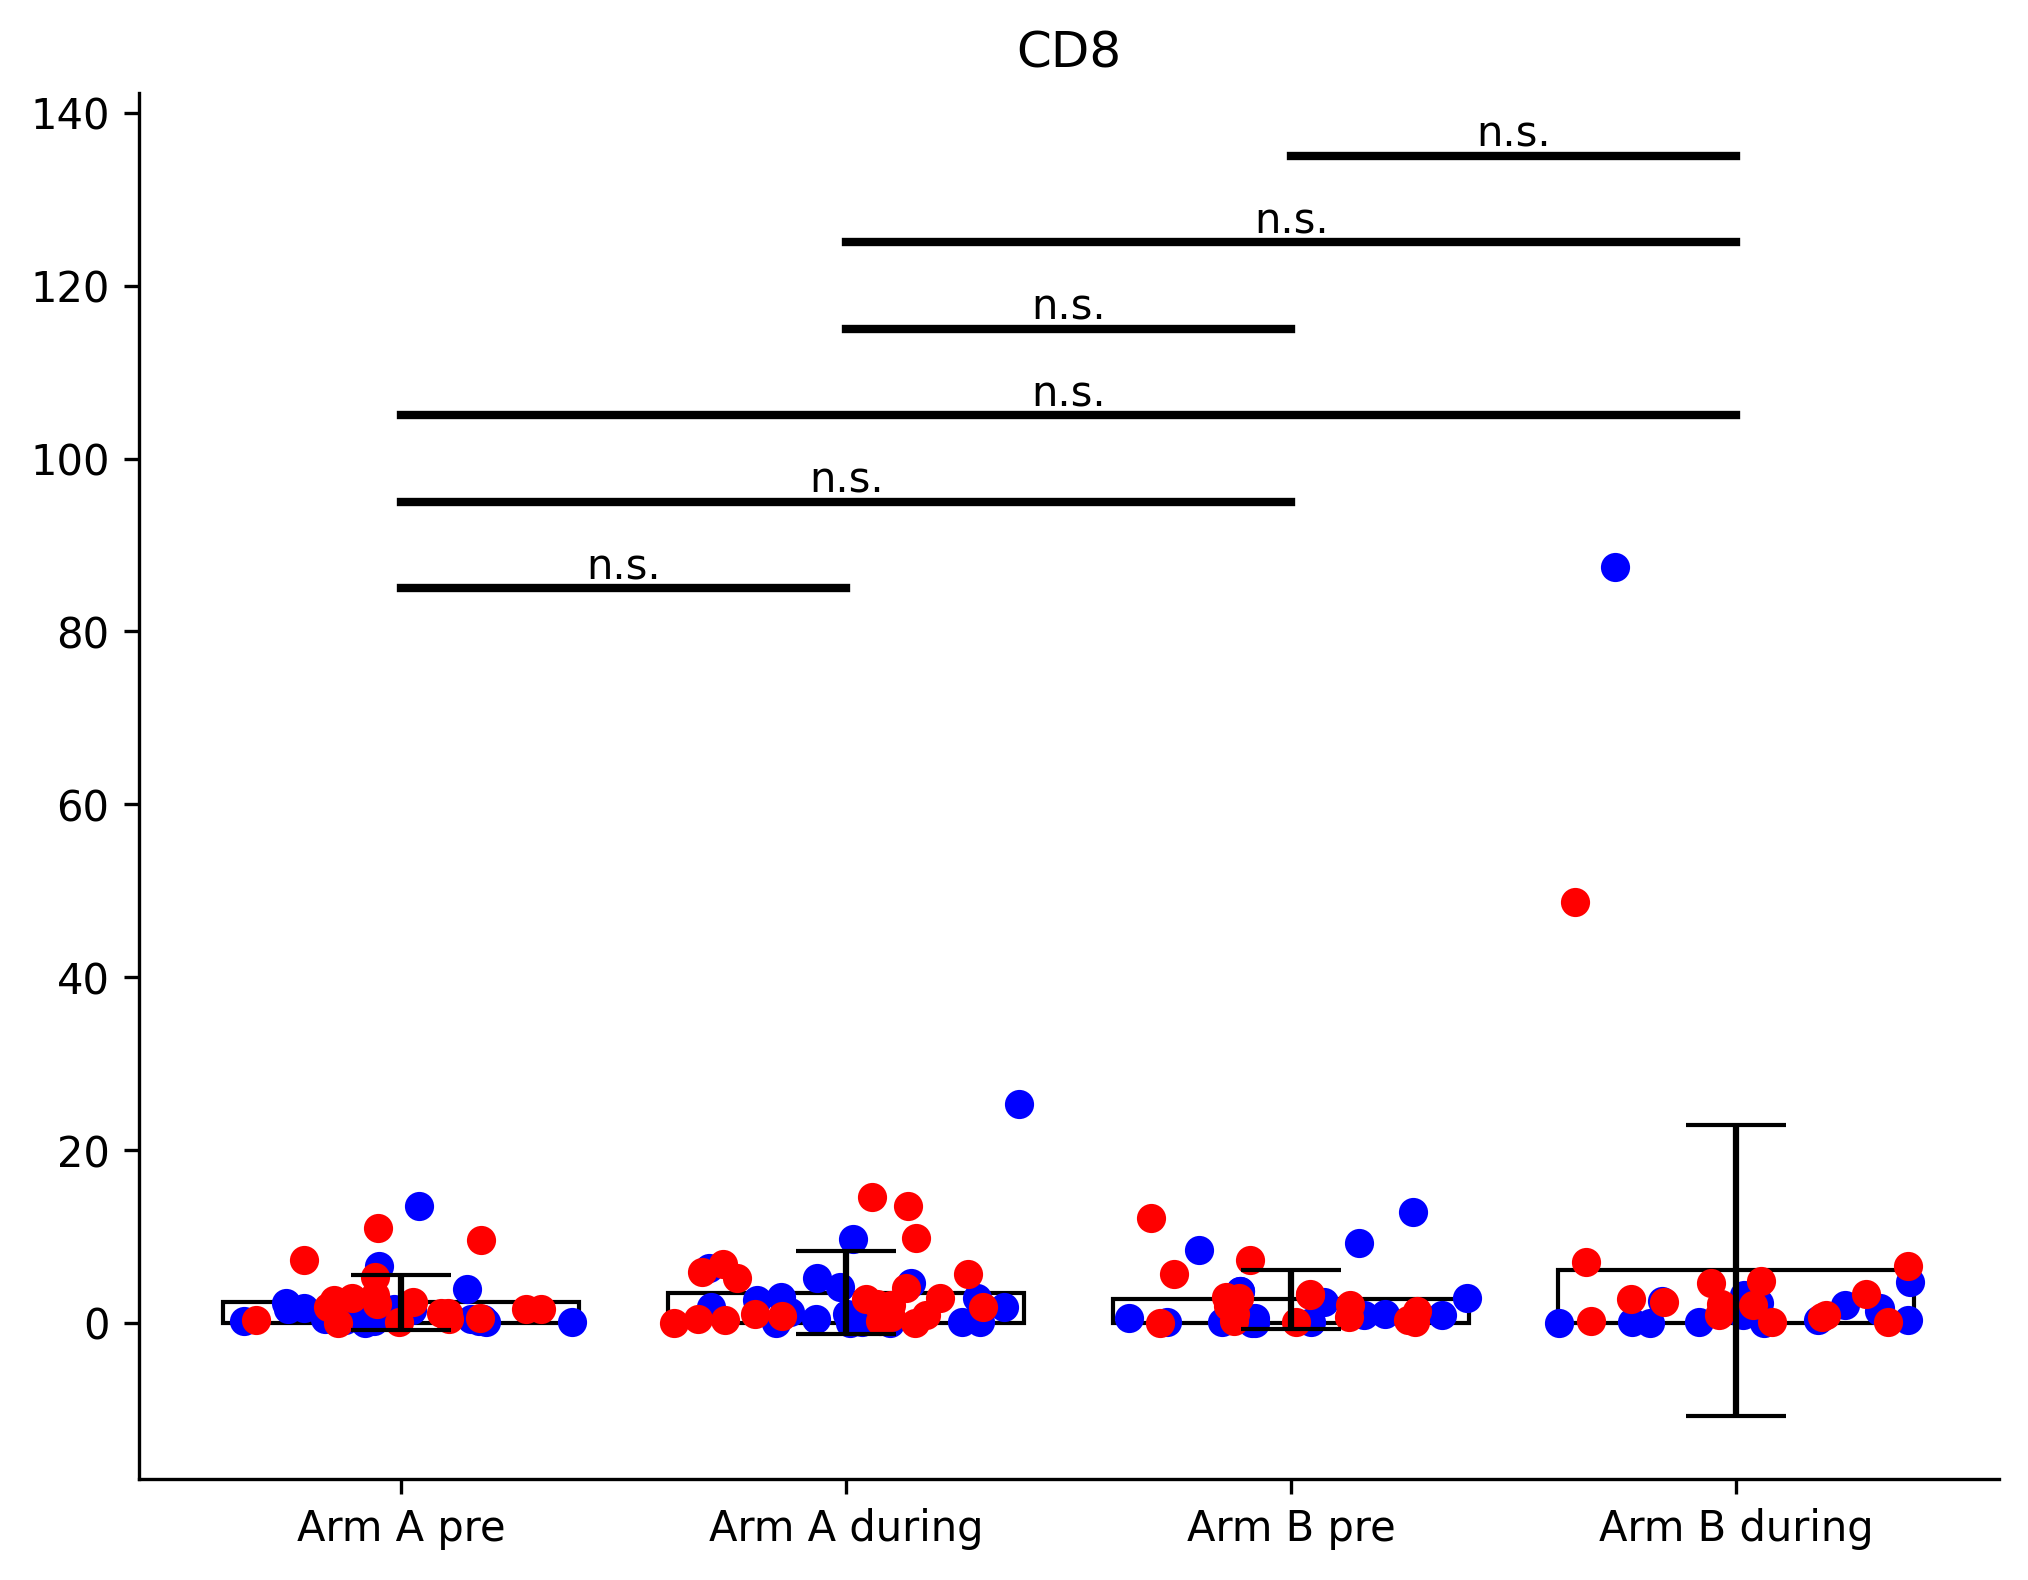

In [16]:
## this code generates the scatter plot for all time points for cd8


np.random.seed(123)

plt.figure(figsize=[8,6],dpi=200)


tx_size = 2.0
fs= 10

#f_a_pre = np.reshape([fox_A_pre_list],[num_pat_A_pre,2])
f_a_pre_stack = np.array(np.concatenate([cd8_A_pre_list_t,cd8_A_pre_list_s],axis=0),dtype=float)

#f_a_dur = np.reshape([fox_A_dur_list],[num_pat_A_dur,2])
f_a_dur_stack = np.array(np.concatenate([cd8_A_dur_list_t,cd8_A_dur_list_s],axis=0),dtype=float)

#f_b_pre = np.reshape([fox_B_pre_list],[num_pat_B_pre,2])
f_b_pre_stack = np.array(np.concatenate([cd8_B_pre_list_t,cd8_B_pre_list_s],axis=0),dtype=float)

#f_b_dur = np.reshape([fox_B_dur_list],[num_pat_B_dur,2])
f_b_dur_stack = np.array(np.concatenate([cd8_B_dur_list_t,cd8_B_dur_list_s],axis=0),dtype=float)

'''stats annotation '''

import pingouin as pg
stats_results = pg.ttest(f_a_pre_stack, f_a_dur_stack, paired=False)
p_val_apre_adur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_adur}")

stats_results = pg.ttest(f_a_pre_stack, f_b_pre_stack, paired=False)
p_val_apre_bpre = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_bpre}")

stats_results = pg.ttest(f_a_pre_stack, f_b_dur_stack, paired=False)
p_val_apre_bdur= stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_bdur}")

stats_results = pg.ttest(f_a_dur_stack, f_b_pre_stack, paired=False)
p_val_adur_bpre = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_adur_bpre}")

stats_results = pg.ttest(f_a_dur_stack, f_b_dur_stack, paired=False)
p_val_adur_bdur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_adur_bdur}")

stats_results = pg.ttest(f_b_pre_stack, f_b_dur_stack, paired=False)
p_val_bpre_bdur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_bpre_bdur}")



l_f_a_pre_stack = np.int64(len(f_a_pre_stack)/2)
l_f_a_dur_stack = np.int64(len(f_a_dur_stack)/2)
l_f_b_pre_stack = np.int64(len(f_b_pre_stack)/2)
l_f_b_dur_stack = np.int64(len(f_b_dur_stack)/2)

w = 0.8    # bar width
x = [1,2,3,4] # x-coordinates of your bars
colors = ['black', 'black', 'black', 'black',(0, 0, 1, 1), (1, 0, 0, 1)]    # corresponding colors
y = [f_a_pre_stack, f_a_dur_stack, f_b_pre_stack, f_b_dur_stack] #,       # data series
    #np.random.random(10) * 3 + 8]

fig, ax = plt.subplots(figsize=[8,6],dpi=300)
ax.bar(x,
       height=[np.mean(yi) for yi in y],
       yerr=[np.std(yi) for yi in y],    # error bars
       capsize=12, # error bar cap width in points
       width=w,    # bar width
       tick_label=["Arm A pre","Arm A during","Arm B pre","Arm B during" ],
       color=(0,0,0,0),  # face color transparent
       edgecolor=colors,
       #ecolor=colors,    # error bar colors;
       )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.xticks(rotation=45)

pat_num = [num_pat_A_pre,num_pat_A_dur,num_pat_B_pre,num_pat_B_dur]
l_ff = [l_f_a_pre_stack,l_f_a_dur_stack,l_f_b_pre_stack,l_f_b_dur_stack]

for i in range(len(x)):
    # distribute scatter randomly across whole width of bar
    ax.scatter(x[i] + np.random.random(l_ff[i]) * w - w / 2, y[i][0:pat_num[i]], color='blue') #colors[i] #tumor
    ax.scatter(x[i] + np.random.random(l_ff[i]) * w - w / 2, y[i][pat_num[i]:pat_num[i]*2], color='red') #colors[i] #stroma

# statistical annotations:
h = 85 # height of the horizontal bar
annotation_offset = 0.01 # offset of the stats-annotation
ax.plot([1, 2], [h, h], '-k', lw=tx_size)
ax.text(1.5, h+annotation_offset, 
         asteriskscheck(p_val_apre_bpre), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)
h = 95 
annotation_offset = 0.01 
ax.plot([1, 3], [h, h], '-k', lw=tx_size)
ax.text(2, h+annotation_offset, 
         asteriskscheck(p_val_apre_adur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 105 
ax.plot([1, 4], [h, h], '-k', lw=tx_size)
annotation_offset = 0.01 
ax.text(2.5, h+annotation_offset, 
         asteriskscheck(p_val_apre_bdur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 115
annotation_offset = 0.01 
ax.plot([2,3], [h, h], '-k', lw=tx_size)
ax.text(2.5, h+annotation_offset, 
         asteriskscheck(p_val_adur_bpre), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 125 
annotation_offset = 0.01
ax.plot([2,4], [h, h], '-k', lw=tx_size)
ax.text(3, h+annotation_offset, 
         asteriskscheck(p_val_adur_bdur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)


h = 135
annotation_offset = 0.01 
ax.plot([3,4], [h, h], '-k', lw=tx_size)
ax.text(3.5, h+annotation_offset, 
         asteriskscheck(p_val_bpre_bdur),
         ha='center', va='bottom', fontsize=fs)

plt.title('CD8')

plt.show()

In [17]:
pv=[p_val_apre_adur,p_val_apre_bpre,p_val_apre_bdur,p_val_adur_bpre,p_val_adur_bdur,p_val_bpre_bdur]
reject, pvals_corr = pg.multicomp(pv, method='holm')
print(reject, pvals_corr)
print(pv)

[False False False False False False] [1. 1. 1. 1. 1. 1.]
[0.2207, 0.6717, 0.2389, 0.4138, 0.4148, 0.2855]


p-value: 0.6737
p-value: 0.2097
p-value: 0.3395
p-value: 0.2389
p-value: 0.4354
p-value: 0.3388


<Figure size 1600x1200 with 0 Axes>

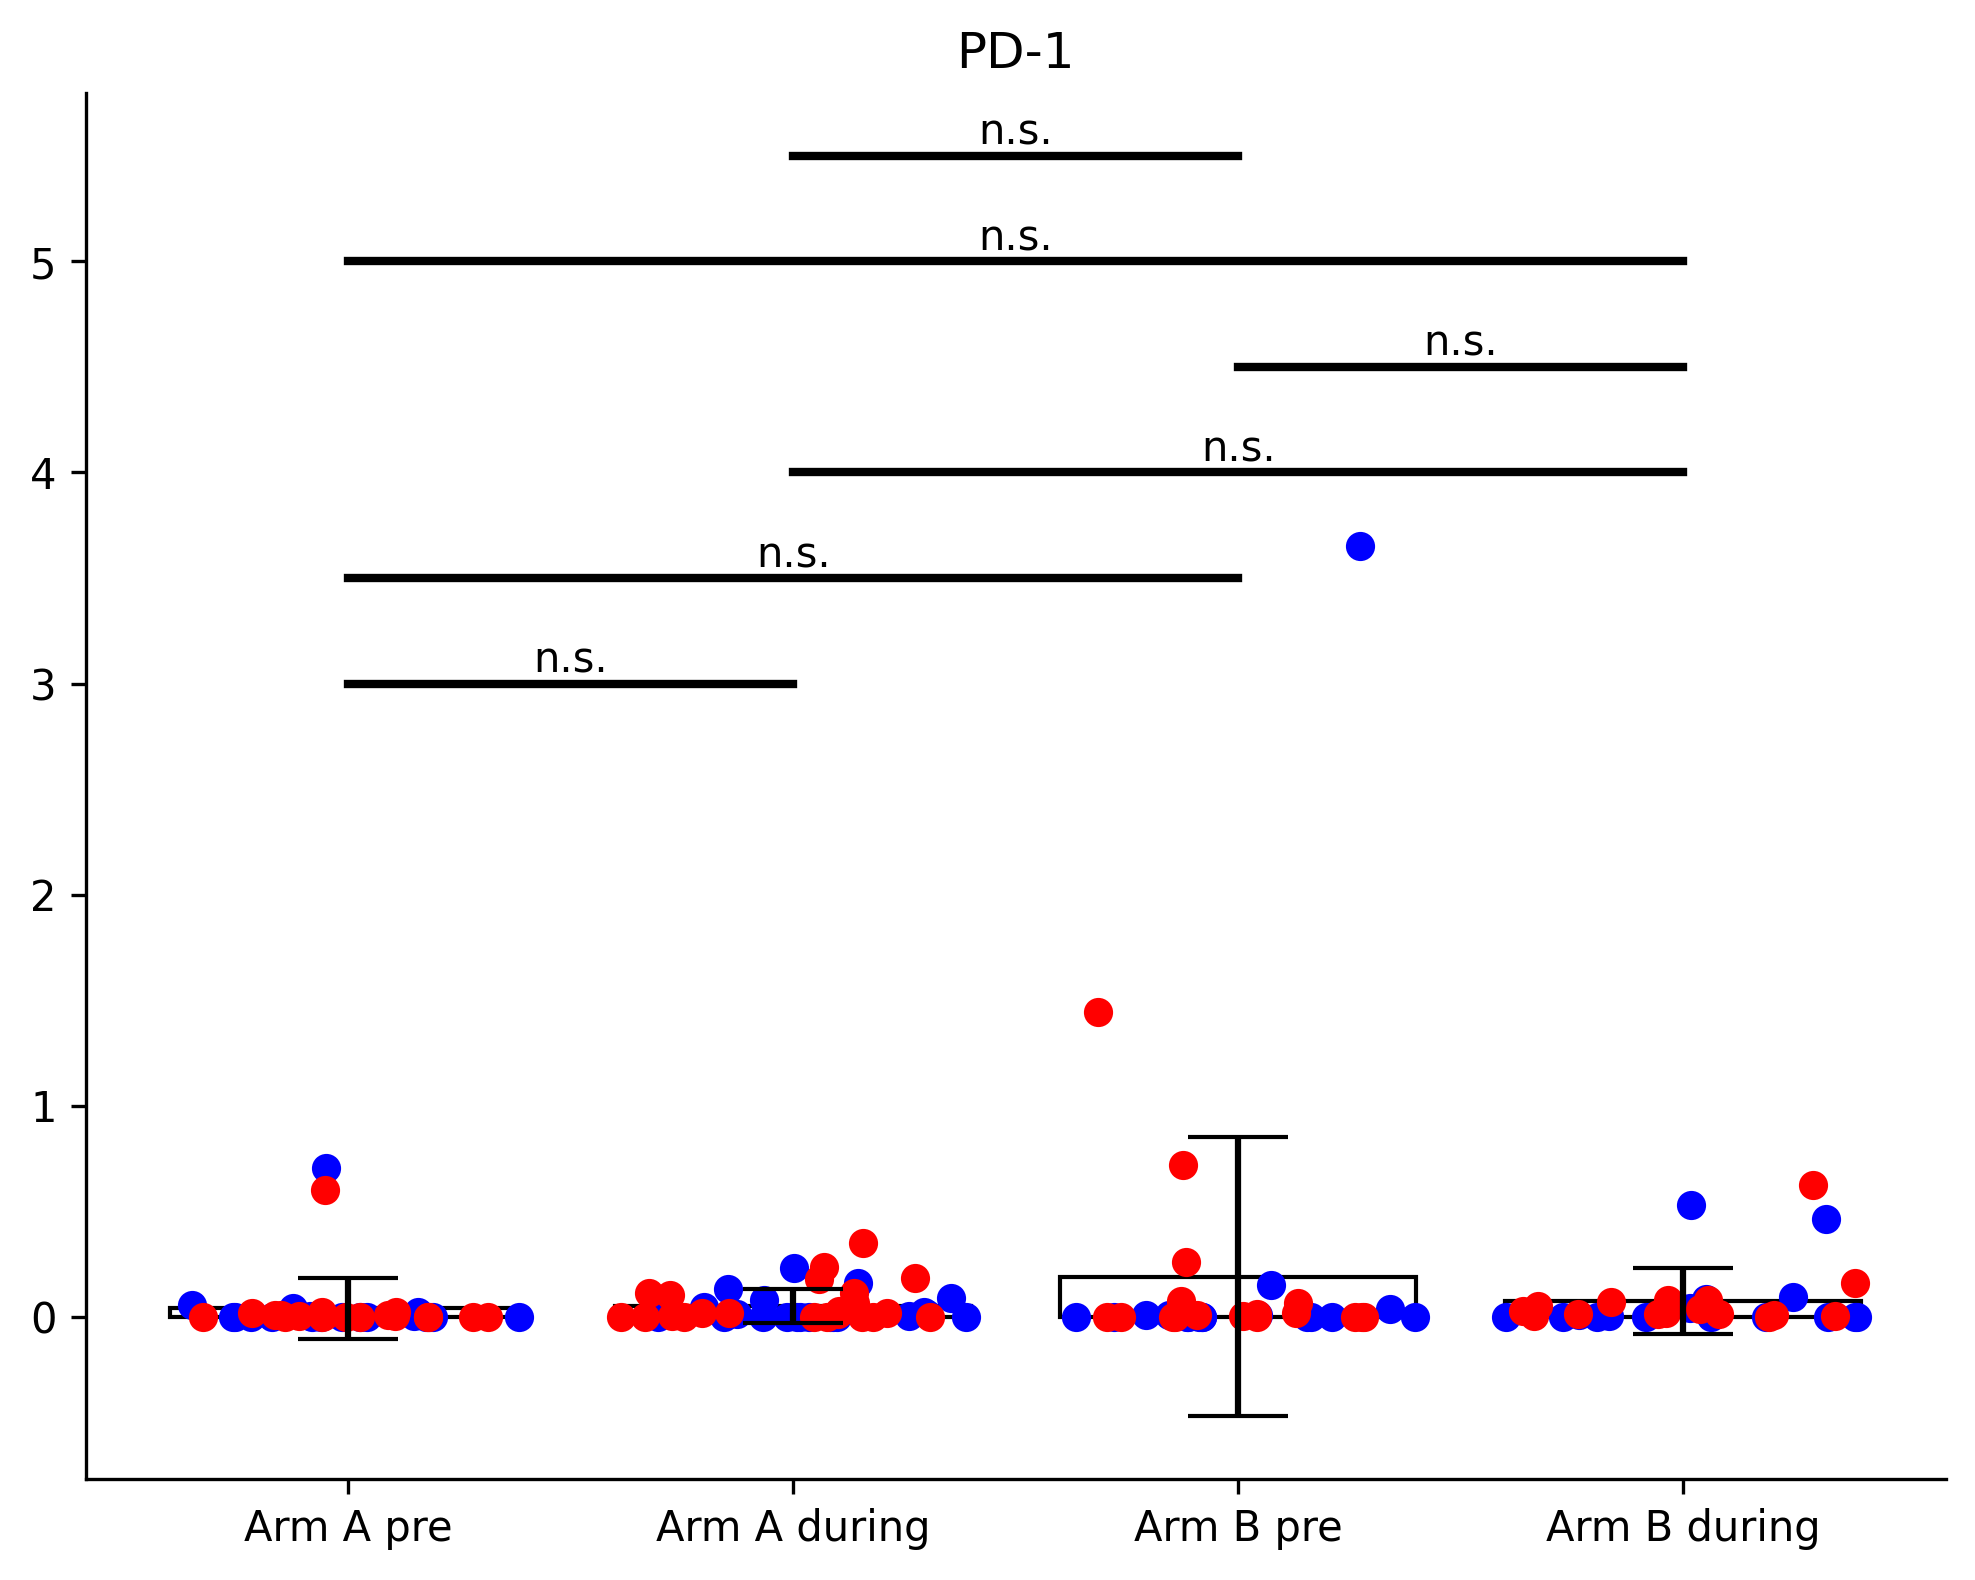

In [18]:
## this code generates the scatter plot for all time points for pd1


np.random.seed(123)

plt.figure(figsize=[8,6],dpi=200)


tx_size = 2.0
fs= 10

#f_a_pre = np.reshape([fox_A_pre_list],[num_pat_A_pre,2])
f_a_pre_stack = np.array(np.concatenate([pd1_A_pre_list_t,pd1_A_pre_list_s],axis=0),dtype=float)

#f_a_dur = np.reshape([fox_A_dur_list],[num_pat_A_dur,2])
f_a_dur_stack = np.array(np.concatenate([pd1_A_dur_list_t,pd1_A_dur_list_s],axis=0),dtype=float)

#f_b_pre = np.reshape([fox_B_pre_list],[num_pat_B_pre,2])
f_b_pre_stack = np.array(np.concatenate([pd1_B_pre_list_t,pd1_B_pre_list_s],axis=0),dtype=float)

#f_b_dur = np.reshape([fox_B_dur_list],[num_pat_B_dur,2])
f_b_dur_stack = np.array(np.concatenate([pd1_B_dur_list_t,pd1_B_dur_list_s],axis=0),dtype=float)

'''stats annotation '''

import pingouin as pg
stats_results = pg.ttest(f_a_pre_stack, f_a_dur_stack, paired=False)
p_val_apre_adur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_adur}")

stats_results = pg.ttest(f_a_pre_stack, f_b_pre_stack, paired=False)
p_val_apre_bpre = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_bpre}")

stats_results = pg.ttest(f_a_pre_stack, f_b_dur_stack, paired=False)
p_val_apre_bdur= stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_bdur}")

stats_results = pg.ttest(f_a_dur_stack, f_b_pre_stack, paired=False)
p_val_adur_bpre = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_adur_bpre}")

stats_results = pg.ttest(f_a_dur_stack, f_b_dur_stack, paired=False)
p_val_adur_bdur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_adur_bdur}")

stats_results = pg.ttest(f_b_pre_stack, f_b_dur_stack, paired=False)
p_val_bpre_bdur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_bpre_bdur}")



l_f_a_pre_stack = np.int64(len(f_a_pre_stack)/2)
l_f_a_dur_stack = np.int64(len(f_a_dur_stack)/2)
l_f_b_pre_stack = np.int64(len(f_b_pre_stack)/2)
l_f_b_dur_stack = np.int64(len(f_b_dur_stack)/2)

w = 0.8    # bar width
x = [1,2,3,4] # x-coordinates of your bars
colors = ['black', 'black', 'black', 'black',(0, 0, 1, 1), (1, 0, 0, 1)]    # corresponding colors
y = [f_a_pre_stack, f_a_dur_stack, f_b_pre_stack, f_b_dur_stack] #,       # data series
    #np.random.random(10) * 3 + 8]

fig, ax = plt.subplots(figsize=[8,6],dpi=300)
ax.bar(x,
       height=[np.mean(yi) for yi in y],
       yerr=[np.std(yi) for yi in y],    # error bars
       capsize=12, # error bar cap width in points
       width=w,    # bar width
       tick_label=["Arm A pre","Arm A during","Arm B pre","Arm B during" ],
       color=(0,0,0,0),  # face color transparent
       edgecolor=colors,
       #ecolor=colors,    # error bar colors; 
       )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.xticks(rotation=45)

pat_num = [num_pat_A_pre,num_pat_A_dur,num_pat_B_pre,num_pat_B_dur]
l_ff = [l_f_a_pre_stack,l_f_a_dur_stack,l_f_b_pre_stack,l_f_b_dur_stack]

for i in range(len(x)):
    # distribute scatter randomly across whole width of bar
    ax.scatter(x[i] + np.random.random(l_ff[i]) * w - w / 2, y[i][0:pat_num[i]], color='blue') #colors[i] #tumor
    ax.scatter(x[i] + np.random.random(l_ff[i]) * w - w / 2, y[i][pat_num[i]:pat_num[i]*2], color='red') #colors[i] #stroma

# statistical annotations:
h = 3 # height of the horizontal bar
annotation_offset = 0.01 # offset of the stats-annotation
ax.plot([1, 2], [h, h], '-k', lw=tx_size)
ax.text(1.5, h+annotation_offset, 
         asteriskscheck(p_val_apre_bpre), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)
h =3.5 
annotation_offset = 0.01 
ax.plot([1, 3], [h, h], '-k', lw=tx_size)
ax.text(2, h+annotation_offset, 
         asteriskscheck(p_val_apre_adur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 5
ax.plot([1, 4], [h, h], '-k', lw=tx_size)
annotation_offset = 0.01 
ax.text(2.5, h+annotation_offset, 
         asteriskscheck(p_val_apre_bdur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 5.5
annotation_offset = 0.01 
ax.plot([2,3], [h, h], '-k', lw=tx_size)
ax.text(2.5, h+annotation_offset, 
         asteriskscheck(p_val_adur_bpre), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 4
annotation_offset = 0.01
ax.plot([2,4], [h, h], '-k', lw=tx_size)
ax.text(3, h+annotation_offset, 
         asteriskscheck(p_val_adur_bdur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)


h = 4.5 
annotation_offset = 0.01 
ax.plot([3,4], [h, h], '-k', lw=tx_size)
ax.text(3.5, h+annotation_offset, 
         asteriskscheck(p_val_bpre_bdur),
         ha='center', va='bottom', fontsize=fs)

plt.title('PD-1')
plt.show()


In [19]:
pv=[p_val_apre_adur,p_val_apre_bpre,p_val_apre_bdur,p_val_adur_bpre,p_val_adur_bdur,p_val_bpre_bdur]
reject, pvals_corr = pg.multicomp(pv, method='holm')
print(reject, pvals_corr)
print(pv)

[False False False False False False] [1. 1. 1. 1. 1. 1.]
[0.6737, 0.2097, 0.3395, 0.2389, 0.4354, 0.3388]


p-value: 0.0837
p-value: 0.1546
p-value: 0.0318
p-value: 0.9855
p-value: 0.3361
p-value: 0.3885


<Figure size 1600x1200 with 0 Axes>

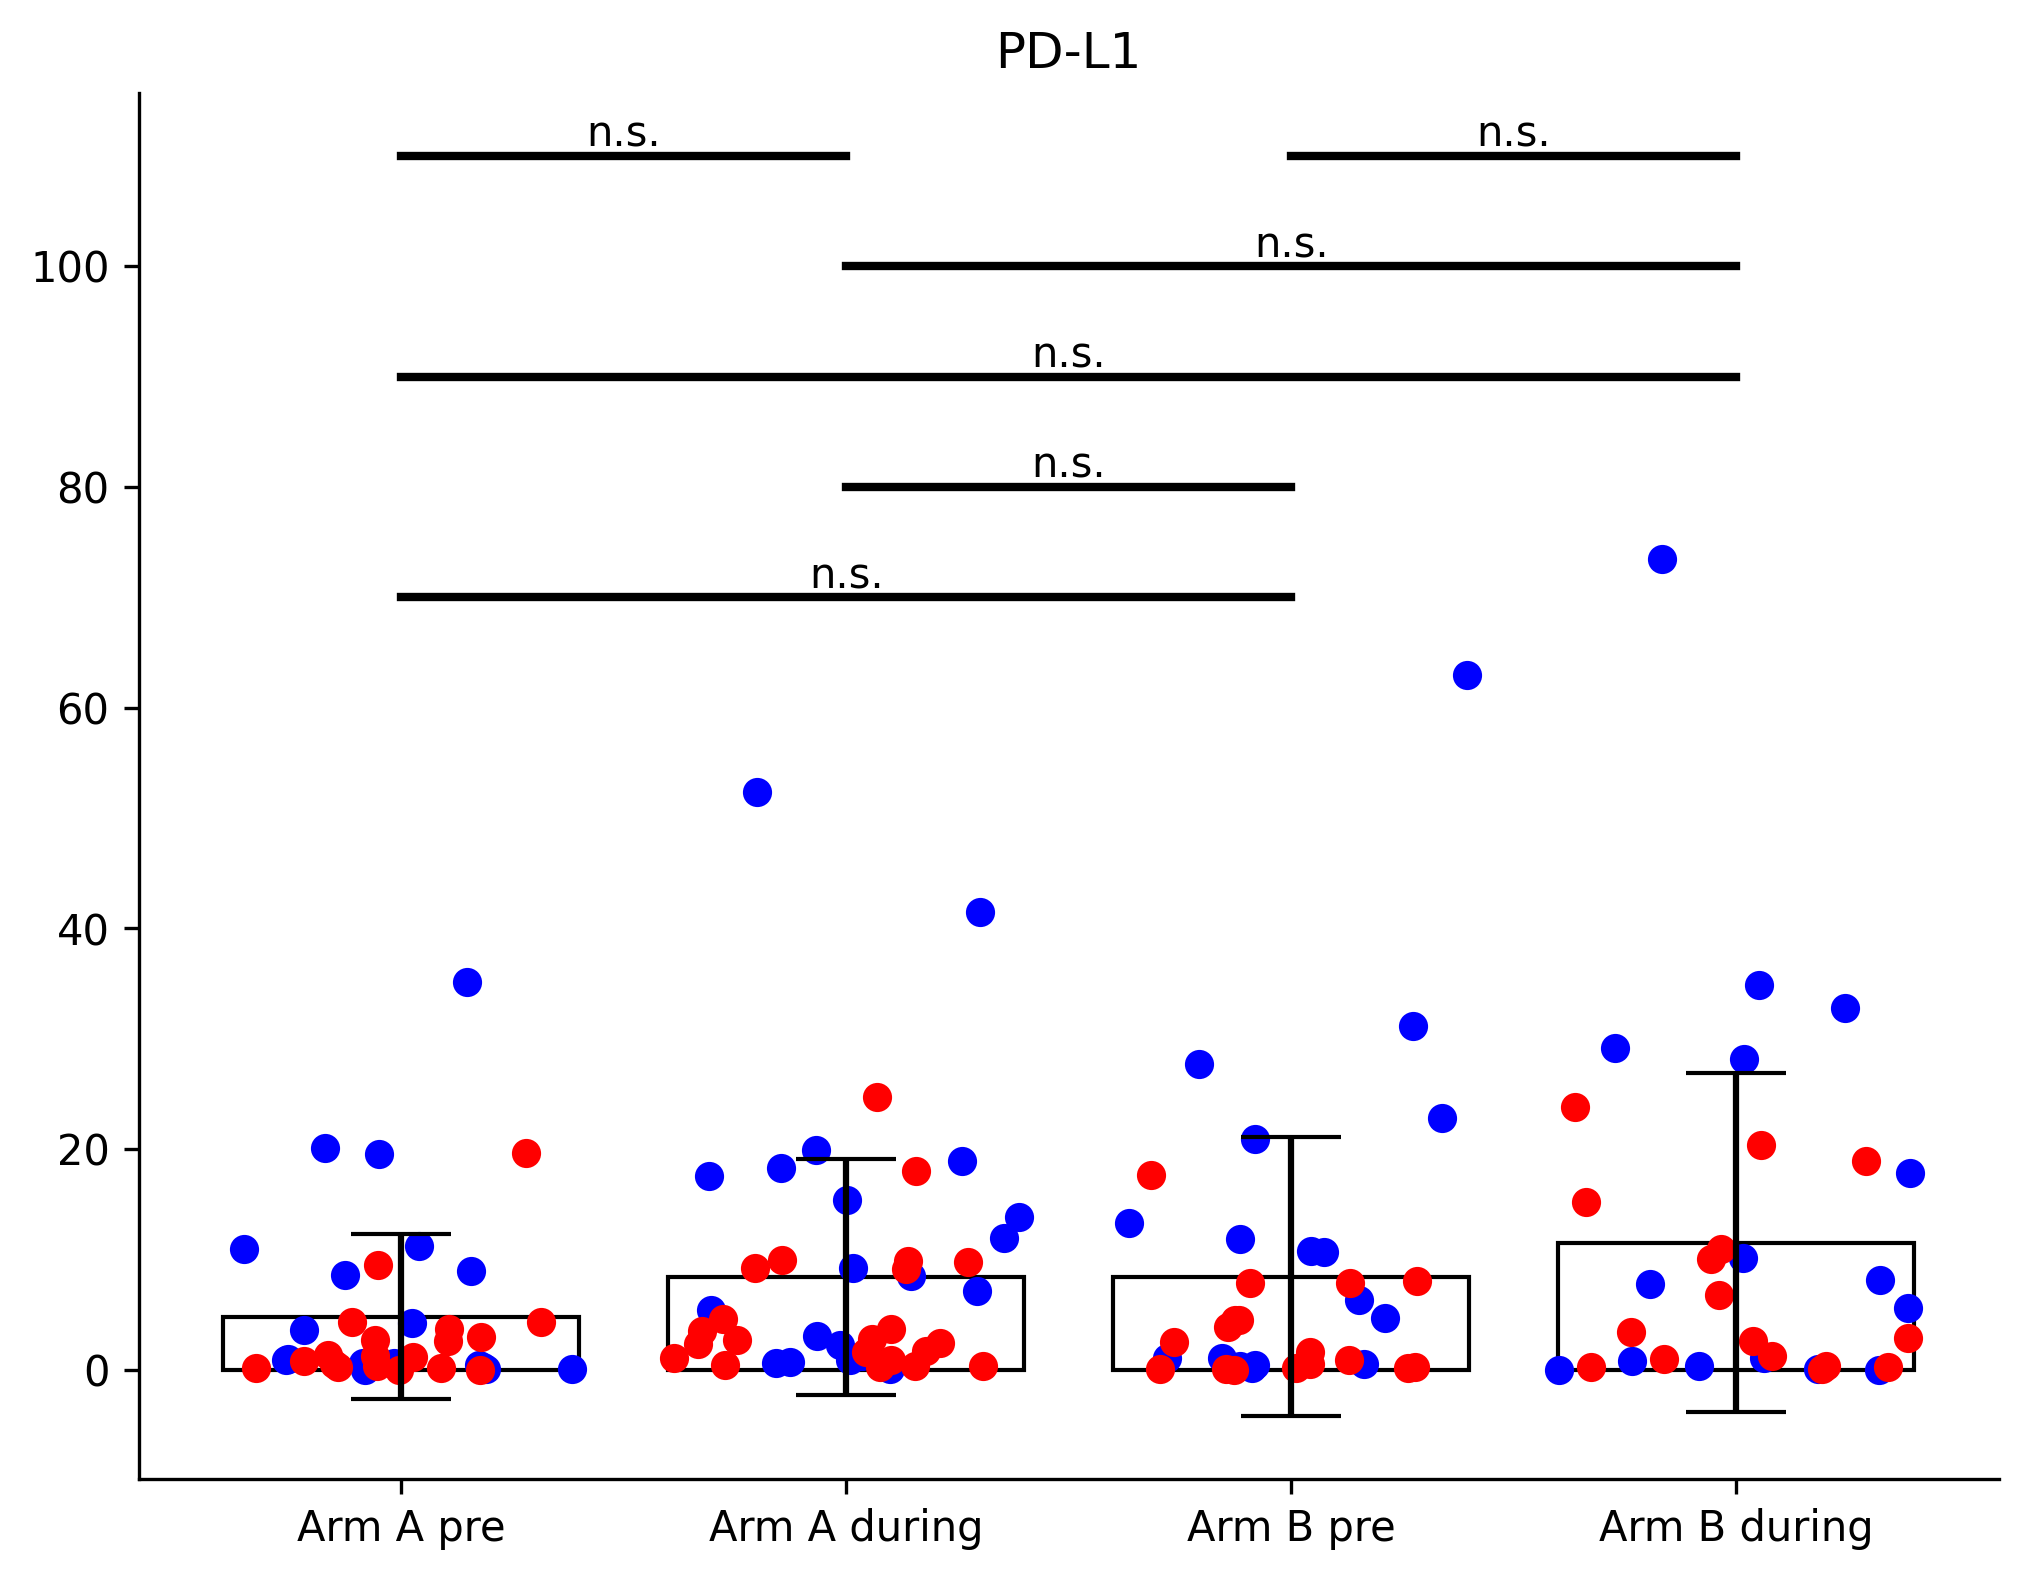

In [20]:
## this code generates the scatter plot for all time points for pdl1


np.random.seed(123)

plt.figure(figsize=[8,6],dpi=200)


tx_size = 2.0
fs= 10

#f_a_pre = np.reshape([fox_A_pre_list],[num_pat_A_pre,2])
f_a_pre_stack = np.array(np.concatenate([pdl1_A_pre_list_t,pdl1_A_pre_list_s],axis=0),dtype=float)

#f_a_dur = np.reshape([fox_A_dur_list],[num_pat_A_dur,2])
f_a_dur_stack = np.array(np.concatenate([pdl1_A_dur_list_t,pdl1_A_dur_list_s],axis=0),dtype=float)

#f_b_pre = np.reshape([fox_B_pre_list],[num_pat_B_pre,2])
f_b_pre_stack = np.array(np.concatenate([pdl1_B_pre_list_t,pdl1_B_pre_list_s],axis=0),dtype=float)

#f_b_dur = np.reshape([fox_B_dur_list],[num_pat_B_dur,2])
f_b_dur_stack = np.array(np.concatenate([pdl1_B_dur_list_t,pdl1_B_dur_list_s],axis=0),dtype=float)

'''stats annotation '''

import pingouin as pg
stats_results = pg.ttest(f_a_pre_stack, f_a_dur_stack, paired=False)
p_val_apre_adur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_adur}")

stats_results = pg.ttest(f_a_pre_stack, f_b_pre_stack, paired=False)
p_val_apre_bpre = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_bpre}")

stats_results = pg.ttest(f_a_pre_stack, f_b_dur_stack, paired=False)
p_val_apre_bdur= stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_apre_bdur}")

stats_results = pg.ttest(f_a_dur_stack, f_b_pre_stack, paired=False)
p_val_adur_bpre = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_adur_bpre}")

stats_results = pg.ttest(f_a_dur_stack, f_b_dur_stack, paired=False)
p_val_adur_bdur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_adur_bdur}")

stats_results = pg.ttest(f_b_pre_stack, f_b_dur_stack, paired=False)
p_val_bpre_bdur = stats_results["p-val"].values[0].round(4)
print(f"p-value: {p_val_bpre_bdur}")



l_f_a_pre_stack = np.int64(len(f_a_pre_stack)/2)
l_f_a_dur_stack = np.int64(len(f_a_dur_stack)/2)
l_f_b_pre_stack = np.int64(len(f_b_pre_stack)/2)
l_f_b_dur_stack = np.int64(len(f_b_dur_stack)/2)

w = 0.8    # bar width
x = [1,2,3,4] # x-coordinates of your bars
colors = ['black', 'black', 'black', 'black',(0, 0, 1, 1), (1, 0, 0, 1)]    # corresponding colors
y = [f_a_pre_stack, f_a_dur_stack, f_b_pre_stack, f_b_dur_stack] #,       # data series
    #np.random.random(10) * 3 + 8]

fig, ax = plt.subplots(figsize=[8,6],dpi=300)
ax.bar(x,
       height=[np.mean(yi) for yi in y],
       yerr=[np.std(yi) for yi in y],    # error bars
       capsize=12, # error bar cap width in points
       width=w,    # bar width
       tick_label=["Arm A pre","Arm A during","Arm B pre","Arm B during" ],
       color=(0,0,0,0),  # face color transparent
       edgecolor=colors,
       #ecolor=colors,    # error bar colors;
       )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.xticks(rotation=45)

pat_num = [num_pat_A_pre,num_pat_A_dur,num_pat_B_pre,num_pat_B_dur]
l_ff = [l_f_a_pre_stack,l_f_a_dur_stack,l_f_b_pre_stack,l_f_b_dur_stack]

for i in range(len(x)):
    # distribute scatter randomly across whole width of bar
    ax.scatter(x[i] + np.random.random(l_ff[i]) * w - w / 2, y[i][0:pat_num[i]], color='blue') #colors[i] #tumor
    ax.scatter(x[i] + np.random.random(l_ff[i]) * w - w / 2, y[i][pat_num[i]:pat_num[i]*2], color='red') #colors[i] #stroma

# statistical annotations:
h = 110 # height of the horizontal bar
annotation_offset = 0.01 # offset of the stats-annotation
ax.plot([1, 2], [h, h], '-k', lw=tx_size)
ax.text(1.5, h+annotation_offset, 
         asteriskscheck(p_val_apre_bpre), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)
h = 70 
annotation_offset = 0.01 
ax.plot([1, 3], [h, h], '-k', lw=tx_size)
ax.text(2, h+annotation_offset, 
         asteriskscheck(p_val_apre_adur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 90
ax.plot([1, 4], [h, h], '-k', lw=tx_size)
annotation_offset = 0.01 
ax.text(2.5, h+annotation_offset, 
         asteriskscheck(p_val_apre_bdur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 80
annotation_offset = 0.01 
ax.plot([2,3], [h, h], '-k', lw=tx_size)
ax.text(2.5, h+annotation_offset, 
         asteriskscheck(p_val_adur_bpre), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)

h = 100
annotation_offset = 0.01
ax.plot([2,4], [h, h], '-k', lw=tx_size)
ax.text(3, h+annotation_offset, 
         asteriskscheck(p_val_adur_bdur), 
        #arrowprops=dict(color='black', lw=2, arrowstyle='-[' ,
         ha='center', va='bottom', fontsize=fs)


h = 110
annotation_offset = 0.01 
ax.plot([3,4], [h, h], '-k', lw=tx_size)
ax.text(3.5, h+annotation_offset, 
         asteriskscheck(p_val_bpre_bdur),
         ha='center', va='bottom', fontsize=fs)

plt.title('PD-L1')

plt.show()


In [21]:
pv=[p_val_apre_adur,p_val_apre_bpre,p_val_apre_bdur,p_val_adur_bpre,p_val_adur_bdur,p_val_bpre_bdur]
reject, pvals_corr = pg.multicomp(pv, method='holm')
print(reject, pvals_corr)
print(pv)

[False False False False False False] [0.4185 0.6184 0.1908 1.     1.     1.    ]
[0.0837, 0.1546, 0.0318, 0.9855, 0.3361, 0.3885]
